In [1]:
# Este comando descarga el repositorio entero a una carpeta llamada 'TFMDS' en Colab.
#!git clone https://github.com/jmorala/TFMDS.git

# Inicializar directorios
Clonar repositorio github
Posicionarse en el directorio raíz

In [2]:
import os

# Detectar si estamos en Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Configurar el directorio de trabajo según el entorno
if IN_COLAB:
    os.chdir('TFMDS')
else:
    # Detectar si estamos en Codespaces o VS Code local
    if os.path.exists('/workspaces/TFMDS'):
        # Entorno Codespaces
        os.chdir('/workspaces/TFMDS')
    else:
        # En VS Code local, nos movemos al directorio raíz del proyecto
        # Usa raw string para evitar errores de escape en rutas Windows
        current_dir = r'C:\Users\jmora\Documents\TFMDS'
        os.chdir(current_dir)

# OPCIONAL: Para verificar que estás en la ruta correcta y ver las carpetas
print("Directorio de trabajo actual:", os.getcwd())

Directorio de trabajo actual: C:\Users\jmora\Documents\TFMDS


In [3]:


import pandas as pd
import numpy as np
import optuna
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import warnings
import time
warnings.filterwarnings('ignore')

# ============================================================================
# IMPORTAR FUNCIONES PERSONALIZADAS
# ============================================================================

from lib.metricas import calcular_metricas, comparar_metricas, resumen_metricas, agregar_estadisticas_error
from lib.graficos import (grafico_real_vs_prediccion, grafico_scatter_prediccion, grafico_comparacion_metricas,
                          grafico_distribucion_error, grafico_feature_importance, dashboard_prediccion)


## Lectura de fichero y adaptación de los tipos


In [4]:

# ============================================================================
# LECTURA DE DATOS
# ============================================================================

df_train = pd.read_csv('datos/df_train.csv', sep=';', parse_dates=['idSecuencia'])
df_test = pd.read_csv('datos/df_test.csv', sep=';', parse_dates=['idSecuencia'])

print("\nInformación de las columnas y tipos de datos:")
print(df_train.info())
print(df_test.info())



Información de las columnas y tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 625800 entries, 0 to 625799
Data columns (total 25 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   idSecuencia         625800 non-null  datetime64[ns]
 1   producto            625800 non-null  int64         
 2   udsVenta            625800 non-null  int64         
 3   bolPromocion        625800 non-null  int64         
 4   bolOpen             625800 non-null  int64         
 5   bolHoliday          625800 non-null  int64         
 6   udsStock            625800 non-null  int64         
 7   rotura_stock        625800 non-null  bool          
 8   dia_semana          625800 non-null  int64         
 9   mes                 625800 non-null  int64         
 10  trimestre           625800 non-null  int64         
 11  semana              625800 non-null  int64         
 12  lag_ventas_1        625800 non-null  fl

# CatBoost

El algoritmo **CatBoost** (Categorical Boosting) es una implementación altamente eficiente, escalable y robusta de los **Gradient Boosting Decision Trees (GBDT)**, desarrollado por Yandex. Es un potente método de **aprendizaje de conjunto (*ensemble*)** que utiliza la estrategia de **Boosting**.

CatBoost es una alternativa recomendada para XGBoost y LightGBM, siendo reconocido por su alto rendimiento, especialmente en tareas con una gran cantidad de características categóricas.

Bases del Algoritmo CatBoost

1.  **Mecanismo de Conjunto (Boosting Secuencial):**
    *   Al igual que otras implementaciones de GBDT, CatBoost entrena secuencialmente una serie de árboles de decisión, donde cada nuevo árbol se enfoca en **corregir los errores** de la suma acumulada de los modelos anteriores.

2.  **Manejo Nativo de Características Categóricas (Innovación Principal):**
    *   La característica más distintiva de CatBoost es su **soporte nativo para variables categóricas** (*out of the box*). No requiere pre-codificación manual de estas características antes del entrenamiento.
    *   CatBoost transforma las características categóricas en valores numéricos **internamente**. Este proceso utiliza un método único de codificación que es similar al **alisado aditivo** (*additive smoothing*).

3.  **Eficiencia y Robustez:**
    *   CatBoost está diseñado para ser eficiente y es una de las implementaciones que se recomienda considerar para **grandes conjuntos de datos de series temporales**.
    *   Junto con LightGBM, CatBoost a menudo se menciona como una de las implementaciones que ha logrado **superar las métricas de XGBoost** en ciertos casos.
    *   El algoritmo también **maneja los valores faltantes de forma nativa**.

En resumen, CatBoost sobresale de sus competidores por su **tratamiento avanzado y robusto de las variables categóricas** directamente en el proceso de *boosting*, lo que elimina la necesidad de ingeniería de características manual para estos tipos de datos y produce un modelo final muy preciso.




# Prearación de datos

In [5]:

# Eliminar días que la tienda está cerrada
df_train = df_train[df_train['bolOpen'] == 1].copy()
df_test = df_test[df_test['bolOpen'] == 1].copy()


In [6]:

# ============================================================================
# CONFIGURACIÓN INICIAL
# ============================================================================

FEATURES = [
    'producto_encoded', 'bolPromocion', 'bolHoliday', 'Cluster',
    'dia_semana', 'mes', 'trimestre',
    'lag_ventas_1', 'lag_ventas_2', 'lag_ventas_3', 'lag_ventas_4',
    'lag_ventas_5', 'lag_ventas_6', 'lag_ventas_7',
    'media_mes_anterior', 'EWMA_corto', 'EWMA_largo', 'Tendencia_EWMA'
]

TARGET = 'udsVenta'

todas_metricas = []

print("="*100)
print("🚀 INICIANDO ANÁLISIS COMPLETO DE CATBOOST")
print("="*100)


🚀 INICIANDO ANÁLISIS COMPLETO DE CATBOOST


# CatBoos global
modelo sobre todas la fechas y productos
Se va utilizar Optuna para buscar los mejores hiperparámetros.
Estos parámetros se utilizarán en los próximos modelos de Random Forest para cluster y productos, se asume que posiblemente serán los mismos parámetros, no se palntea utilizar optuna en el resto de modelos por el coste de tiempo que lleva

In [7]:

# ============================================================================
# 1. MODELO GLOBAL CON OPTUNA (CatBoost)
# ============================================================================

print("\n" + "="*100)
print("🔍 MODELO 1: CATBOOST GLOBAL")
print("="*100)

# Preparar datos
X_train = df_train[FEATURES]
y_train = df_train[TARGET]
X_test = df_test[FEATURES]
y_test = df_test[TARGET]

print(f"\n✅ X_train shape: {X_train.shape}")
print(f"✅ X_test shape: {X_test.shape}")

# Último 20% como validación temporal
VAL_SIZE = int(len(X_train) * 0.2)

X_tr = X_train.iloc[:-VAL_SIZE]
y_tr = y_train.iloc[:-VAL_SIZE]

X_val = X_train.iloc[-VAL_SIZE:]
y_val = y_train.iloc[-VAL_SIZE:]

print(f"\n✅ X_tr shape: {X_tr.shape}")
print(f"✅ X_val shape: {X_val.shape}")
print(f"✅ y_tr shape: {y_tr.shape}")
print(f"✅ y_val shape: {y_val.shape}")



🔍 MODELO 1: CATBOOST GLOBAL

✅ X_train shape: (521202, 18)
✅ X_test shape: (23244, 18)

✅ X_tr shape: (416962, 18)
✅ X_val shape: (104240, 18)
✅ y_tr shape: (416962,)
✅ y_val shape: (104240,)


In [8]:
print("\n🔎 Búsqueda de hiperparámetros con Optuna para CatBoost...")

# =====================================================
#  FUNCION OBJETIVO DE OPTUNA PARA CATBOOST
# =====================================================

def objective_catboost(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 300, 1200),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'random_strength': trial.suggest_float('random_strength', 0, 10),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 100),
        'loss_function': 'RMSE',
        'eval_metric': 'RMSE',
        'random_seed': 42,
        'verbose': False,
        'early_stopping_rounds': 50
    }

    model = CatBoostRegressor(**params)
    
    model.fit(
        X_tr, y_tr,
        eval_set=(X_val, y_val),
        verbose=False
    )
    
    preds = model.predict(X_val)
    mse = mean_squared_error(y_val, preds)
    return mse

# =====================================================
#  EJECUTAR OPTUNA
# =====================================================
print("\n🔍 Iniciando optimización de hiperparámetros con Optuna para CatBoost...")
start_time = time.perf_counter()

study_catboost = optuna.create_study(direction='minimize')
study_catboost.optimize(objective_catboost, n_trials=5, n_jobs=1)

elapsed = time.perf_counter() - start_time
print(f"✅ Optuna completado en {elapsed:.2f} segundos")

print("\n🏆 Mejores hiperparámetros CatBoost:")
print(study_catboost.best_params)


[I 2025-12-01 17:05:07,937] A new study created in memory with name: no-name-5c8e5cf3-959a-4816-887a-45b28204722e



🔎 Búsqueda de hiperparámetros con Optuna para CatBoost...

🔍 Iniciando optimización de hiperparámetros con Optuna para CatBoost...


[I 2025-12-01 17:05:33,575] Trial 0 finished with value: 3.909560885898127 and parameters: {'iterations': 686, 'learning_rate': 0.012338159003242987, 'depth': 4, 'l2_leaf_reg': 6.183603107366998, 'bagging_temperature': 0.47177603724717077, 'random_strength': 3.5811670706263508, 'border_count': 96, 'min_data_in_leaf': 57}. Best is trial 0 with value: 3.909560885898127.
[I 2025-12-01 17:05:56,672] Trial 1 finished with value: 3.883873427929224 and parameters: {'iterations': 1006, 'learning_rate': 0.0537452180688698, 'depth': 10, 'l2_leaf_reg': 9.838602763563324, 'bagging_temperature': 0.8280684923884691, 'random_strength': 0.6763525093637257, 'border_count': 136, 'min_data_in_leaf': 81}. Best is trial 1 with value: 3.883873427929224.
[I 2025-12-01 17:06:13,259] Trial 2 finished with value: 3.90111097955924 and parameters: {'iterations': 1056, 'learning_rate': 0.05349188834505923, 'depth': 5, 'l2_leaf_reg': 4.697232616224376, 'bagging_temperature': 0.5235395901538361, 'random_strength': 6

✅ Optuna completado en 100.96 segundos

🏆 Mejores hiperparámetros CatBoost:
{'iterations': 1006, 'learning_rate': 0.0537452180688698, 'depth': 10, 'l2_leaf_reg': 9.838602763563324, 'bagging_temperature': 0.8280684923884691, 'random_strength': 0.6763525093637257, 'border_count': 136, 'min_data_in_leaf': 81}


In [11]:
best_catboost = CatBoostRegressor(
    **study_catboost.best_params,
    random_state=42)

best_catboost.fit(X_train, y_train, verbose=False)


In [12]:

from lib.utils import obtener_top_productos_por_cluster

# Predicciones
y_test_pred = best_catboost.predict(X_test)

# Calcular métricas
metricas_test_global = calcular_metricas(y_test, y_test_pred, 'CatBoost Global Test')

todas_metricas.append(metricas_test_global)

print("\n📊 Métricas del Modelo Global:")
resumen_metricas([metricas_test_global])

# Calcular métricas por cluster y guardar
for cluster in df_test['Cluster'].unique():
    y_test_pred_cl = y_test_pred[X_test['Cluster'] == cluster]
    y_test_cl = y_test[X_test['Cluster'] == cluster]
    metricas_cluster = calcular_metricas(y_test_cl, y_test_pred_cl, f'CatBoost Global Cluster {cluster}')
    todas_metricas.append(metricas_cluster)
    
# Calcular métricas por producto top en cada cluster
top_productos = obtener_top_productos_por_cluster(
    df=df_train,
    col_ventas='udsVenta',
    col_cluster='Cluster',
    col_producto='producto',
    n_productos=2
)

for cluster, productos in top_productos.items():
    for producto in productos:
        idx_producto = (df_test['Cluster'] == cluster) & (df_test['producto'] == producto)
        y_test_prod = y_test[idx_producto]
        y_test_pred_prod = y_test_pred[idx_producto]
        metricas_producto = calcular_metricas(y_test_prod, y_test_pred_prod, f'CatBoost Global Cluster {cluster} Producto {producto}')
        todas_metricas.append(metricas_producto)

resumen_metricas(todas_metricas)    





📊 Métricas del Modelo Global:

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE    MSE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
CatBoost Global Test 1.5724 5.7105 2.3897 0.2548     49.73     144.66 0.7323     96.3

🏆 Mejor modelo: CatBoost Global Test (RMSE: 2.3897)

📊 RESUMEN DE MÉTRICAS
                             Algoritmo    MAE      MSE    RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
CatBoost Global Cluster 3 Producto 314 0.3829   0.1626  0.4032  0.0000       NaN     200.00    NaN      NaN
CatBoost Global Cluster 3 Producto 257 0.8904   1.3331  1.1546 -0.0046     74.18     184.98 0.7856   178.08
             CatBoost Global Cluster 3 1.0844   2.7448  1.6567  0.0803     55.20     168.95 0.7434   133.53
CatBoost Global Cluster 0 Producto 413 1.6570   4.5775  2.1395  0.0543     32.10     101.67 0.7490    79.78
                  CatBoost Global Test 1.5724   5.7105  2.3897  0.2548     49.73     144.66 0.7323    96.30
             CatBoost Global Cluster 0 1.8068   6.

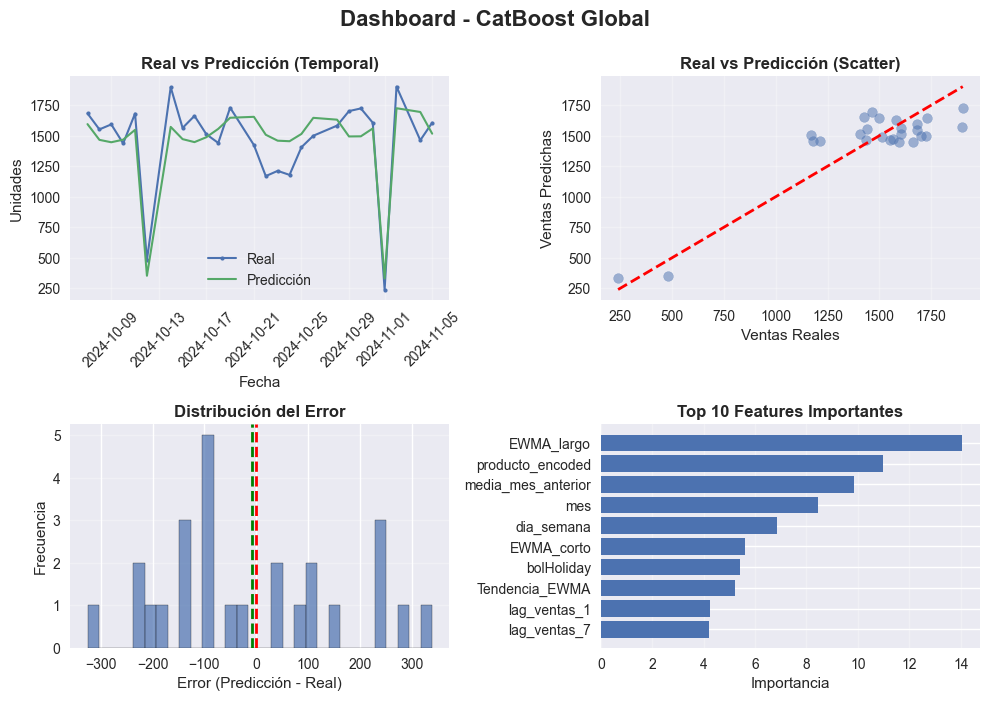

In [13]:

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')

# Visualizaciones del modelo global
df_test_viz = df_test.copy()
df_test_viz['prediccion'] = y_test_pred
#df_test_viz['error'] = y_test_pred - df_test_viz[TARGET]
df_test_viz_sum = df_test_viz.groupby('idSecuencia')[[TARGET, 'prediccion']].sum().reset_index()
df_test_viz_sum['error'] = df_test_viz_sum['prediccion'] - df_test_viz_sum[TARGET]

dashboard_prediccion(
        df=df_test_viz_sum,
        col_fecha='idSecuencia',
        col_real=TARGET,
        col_pred='prediccion',
        modelo=best_catboost,
        feature_names=FEATURES,
        titulo_principal=f'Dashboard - CatBoost Global',
        figsize=(10, 7)
        )


# CatBoost por Cluster


🔍 MODELO 2: CATBOOST POR CLUSTER

🔄 Entrenando modelo para Cluster 0...

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE    MSE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
  CatBoost Cluster 0 1.8065 6.5446 2.5582 0.1109     40.17     126.01 0.7354    93.56

🏆 Mejor modelo: CatBoost Cluster 0 (RMSE: 2.5582)


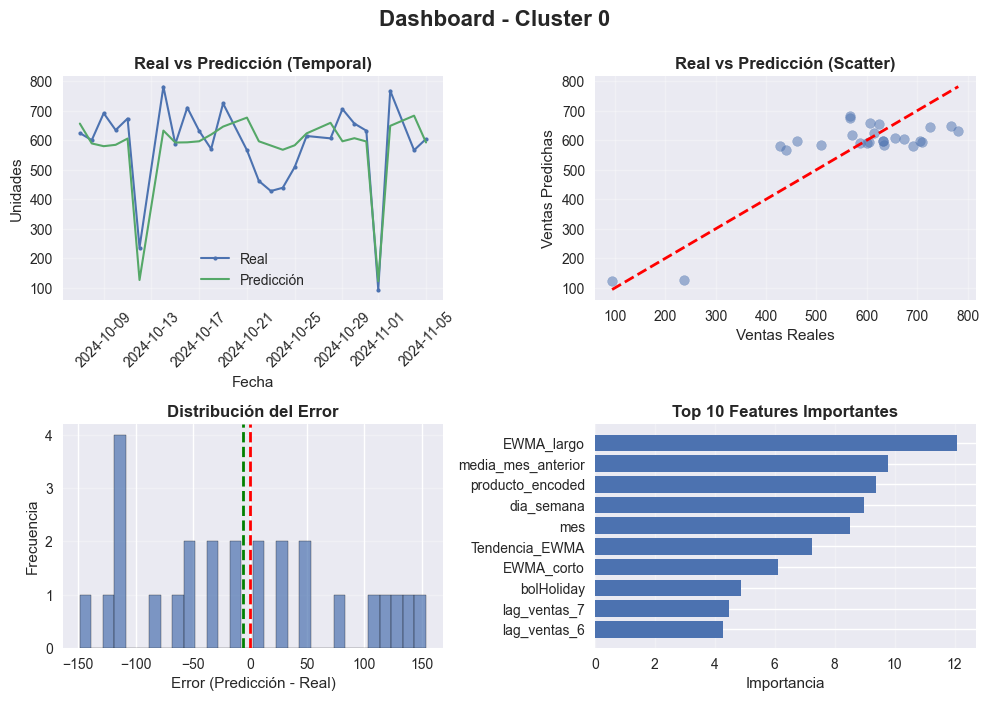


🔄 Entrenando modelo para Cluster 1...

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE     MSE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
  CatBoost Cluster 1 2.7893 13.1068 3.6203 0.1282     56.12      99.22 0.7236    73.15

🏆 Mejor modelo: CatBoost Cluster 1 (RMSE: 3.6203)


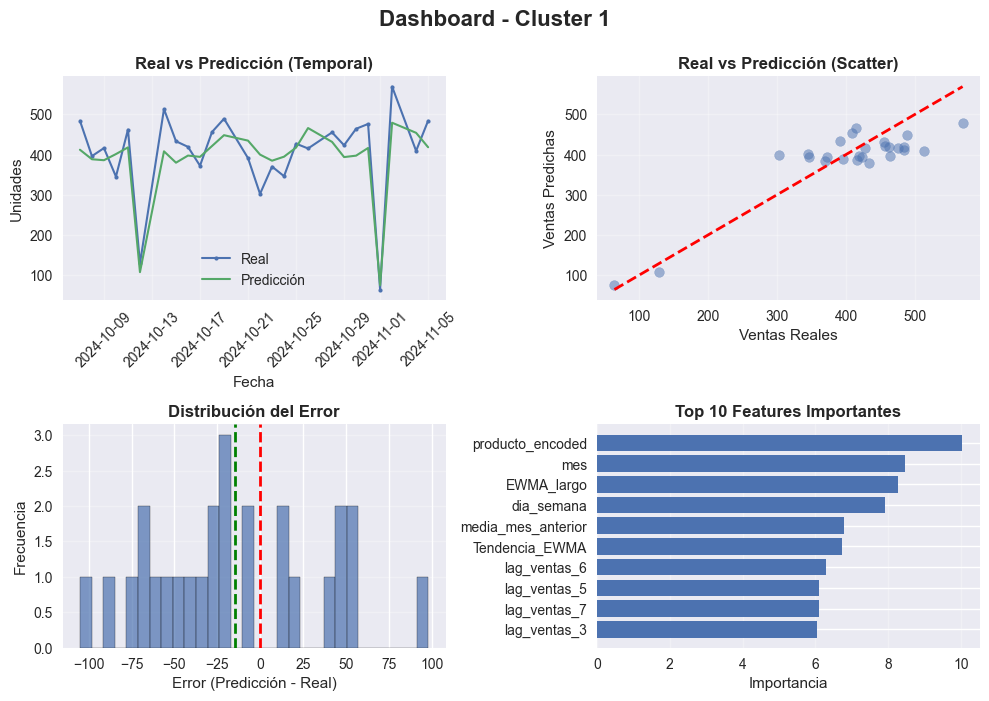


🔄 Entrenando modelo para Cluster 2...

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE     MSE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
  CatBoost Cluster 2 3.6912 26.3773 5.1359 0.1849     73.98      81.58 0.7142    64.28

🏆 Mejor modelo: CatBoost Cluster 2 (RMSE: 5.1359)


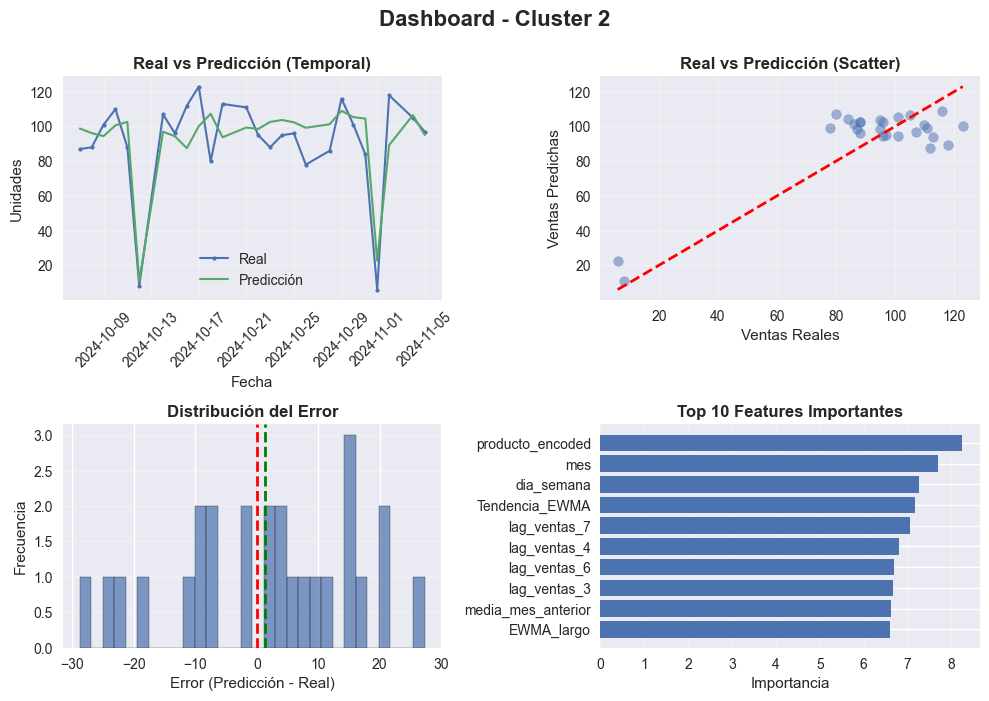


🔄 Entrenando modelo para Cluster 3...

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE    MSE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
  CatBoost Cluster 3 1.0891 2.7976 1.6726 0.0626     55.66     169.06 0.7506    134.1

🏆 Mejor modelo: CatBoost Cluster 3 (RMSE: 1.6726)


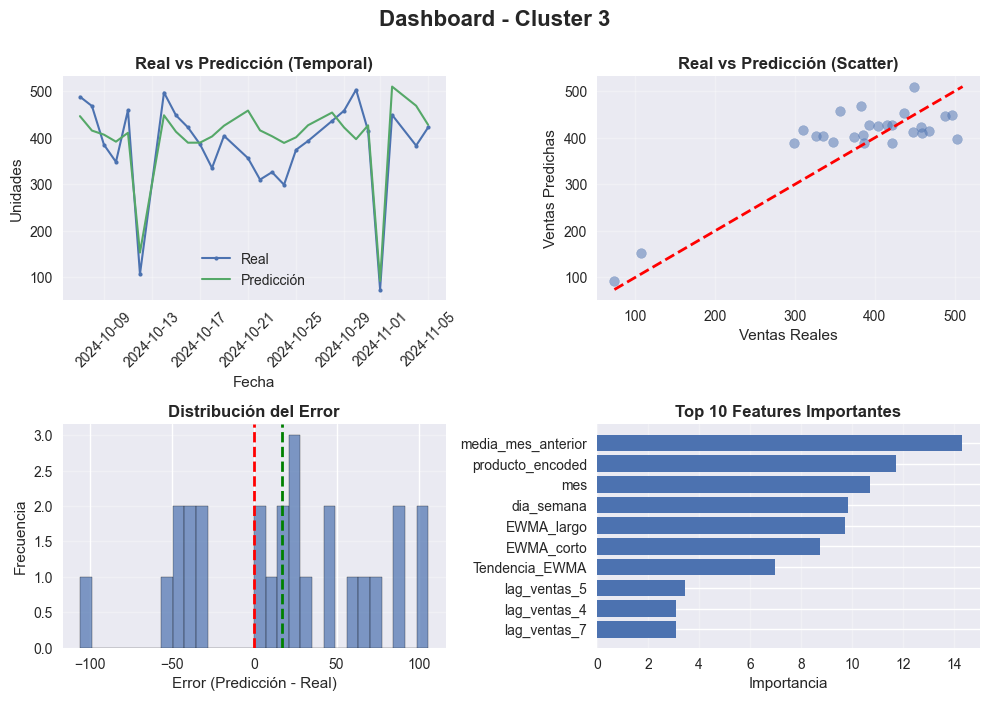

In [15]:

# ============================================================================
# 2. MODELOS POR CLUSTER
# ============================================================================

print("\n" + "="*100)
print("🔍 MODELO 2: CATBOOST POR CLUSTER")
print("="*100)

modelos_cluster = {}

for cluster in sorted(df_train['Cluster'].unique()):
    print(f"\n🔄 Entrenando modelo para Cluster {cluster}...")
    
    # Filtrar datos
    train_cluster = df_train[df_train['Cluster'] == cluster]
    test_cluster = df_test[df_test['Cluster'] == cluster].dropna()
    
    if len(test_cluster) == 0:
        print(f"   ⚠️  No hay datos de validación")
        continue
    
    X_train_c = train_cluster[FEATURES]
    y_train_c = train_cluster[TARGET]
    X_test_c = test_cluster[FEATURES]
    y_test_c = test_cluster[TARGET]
      
    # Entrenar
    catboost_cluster = CatBoostRegressor(
        **study_catboost.best_params,
        random_state=42)
    
    catboost_cluster.fit(X_train_c, y_train_c, verbose=False)
    y_pred_c = catboost_cluster.predict(X_test_c)
    
    # Calcular métricas
    metricas_cluster = calcular_metricas(y_test_c, y_pred_c, f"CatBoost Cluster {cluster}")
    todas_metricas.append(metricas_cluster)
    
    
    # Calcular métricas por producto top en cada cluster
    top_productos = obtener_top_productos_por_cluster(
        df=train_cluster,
        col_ventas='udsVenta',
        col_cluster='Cluster',
        col_producto='producto',
        n_productos=2
    ) 
    
    for producto in top_productos.get(cluster, []):
        idx_producto = (test_cluster['producto'] == producto)
        y_test_prod = y_test_c[idx_producto]
        y_test_pred_prod = y_pred_c[idx_producto]
        metricas_producto = calcular_metricas(y_test_prod, y_test_pred_prod, f'XGBoost Cluster {cluster} Producto {producto}')
        todas_metricas.append(metricas_producto)
    
    resumen_metricas([metricas_cluster])
    
    # Visualizaciones del modelo cluster
    df_test_viz = test_cluster.copy()
    df_test_viz['prediccion'] = y_pred_c
    df_test_viz_sum = df_test_viz.groupby('idSecuencia')[[TARGET, 'prediccion']].sum().reset_index()
    df_test_viz_sum['error'] = df_test_viz_sum['prediccion'] - df_test_viz_sum[TARGET]
    
    dashboard_prediccion(
        df=df_test_viz_sum,
        col_fecha='idSecuencia',
        col_real=TARGET,
        col_pred='prediccion',
        modelo=catboost_cluster,
        feature_names=FEATURES,
        titulo_principal=f'Dashboard - Cluster {cluster}',
        figsize=(10, 7)
        )



# CatBoost por top 2 productos de ventas por cluster


📍 MODELO 3: XGBoost POR PRODUCTO TOP (2 POR CLUSTER)

🎯 CLUSTER 0 - Top 2 productos

🔄 Entrenando modelo para Producto 413 (Cluster 0)...

📊 RESUMEN DE MÉTRICAS
                 Algoritmo    MAE   MSE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
CatBoost Producto 413 (C0) 1.9187 5.377 2.3188 -0.1109     43.69     108.94 0.8118    92.38

🏆 Mejor modelo: CatBoost Producto 413 (C0) (RMSE: 2.3188)


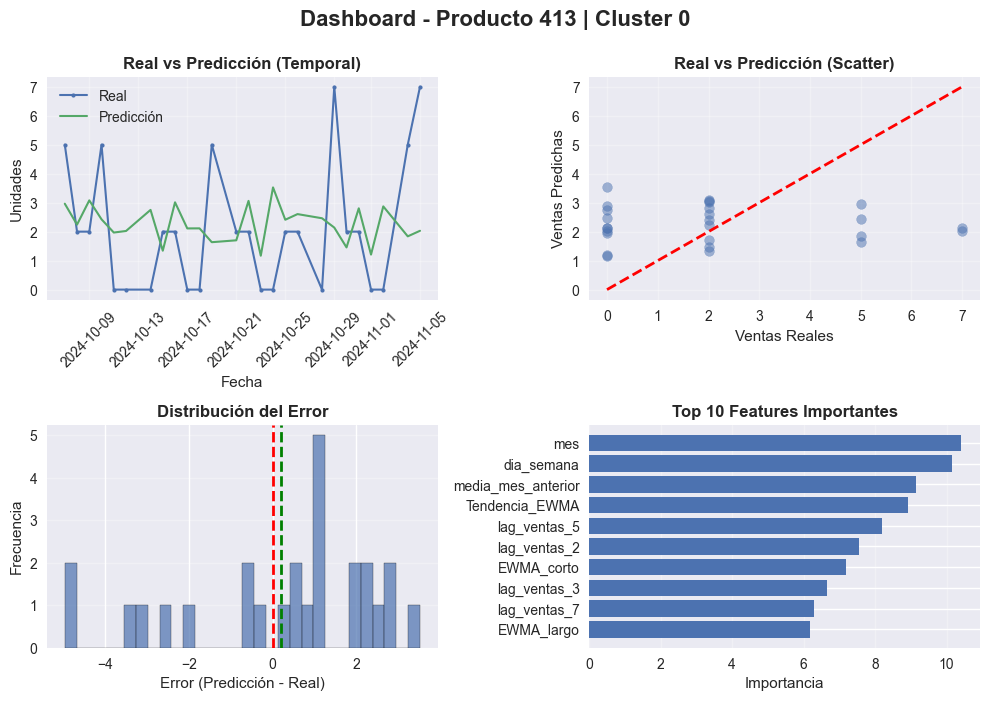


🔄 Entrenando modelo para Producto 294 (Cluster 0)...

📊 RESUMEN DE MÉTRICAS
                 Algoritmo   MAE     MSE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
CatBoost Producto 294 (C0) 2.791 12.4091 3.5227 -0.5557     81.27     146.88 0.8116   151.18

🏆 Mejor modelo: CatBoost Producto 294 (C0) (RMSE: 3.5227)


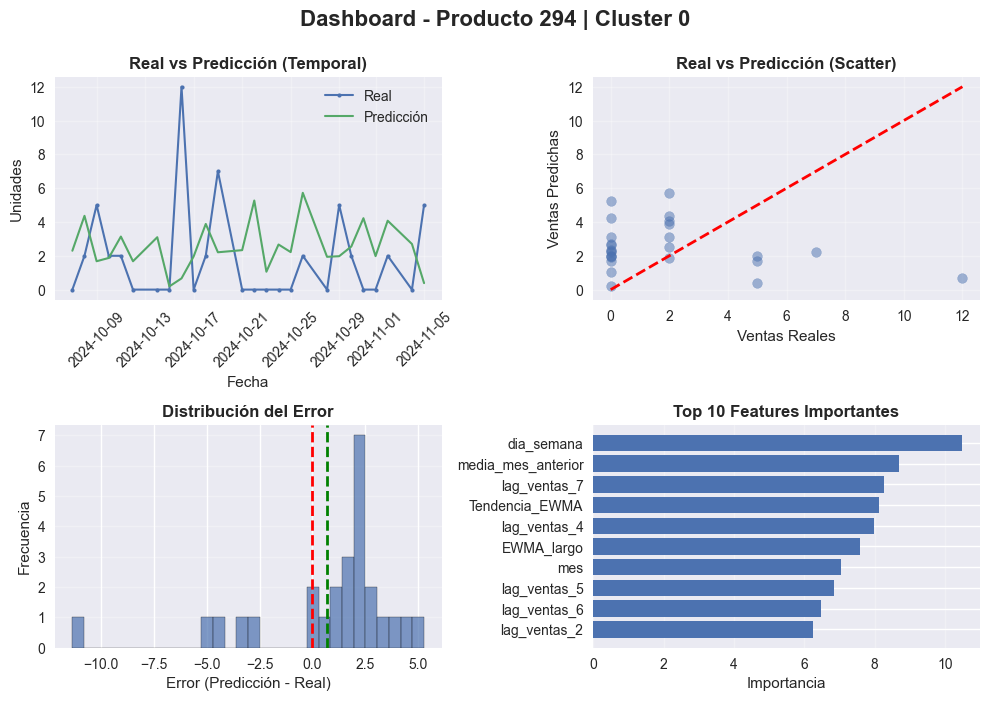


🎯 CLUSTER 1 - Top 2 productos

🔄 Entrenando modelo para Producto 144 (Cluster 1)...

📊 RESUMEN DE MÉTRICAS
                 Algoritmo    MAE    MSE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
CatBoost Producto 144 (C1) 4.0944 25.864 5.0857 -0.0069     83.14      86.35 0.7602    72.42

🏆 Mejor modelo: CatBoost Producto 144 (C1) (RMSE: 5.0857)


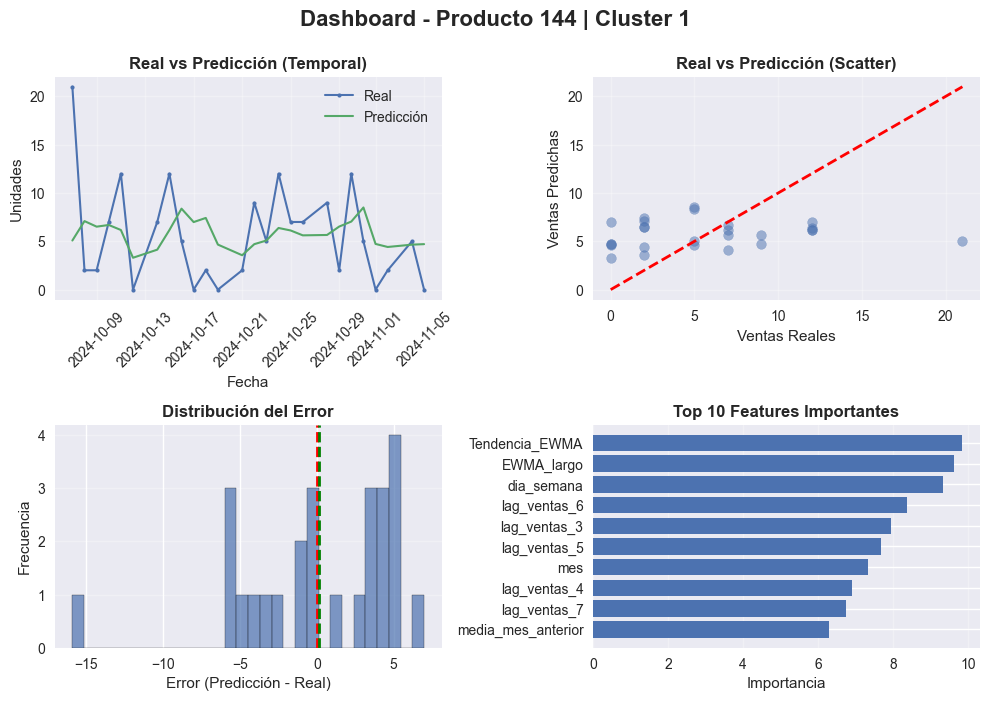


🔄 Entrenando modelo para Producto 41 (Cluster 1)...

📊 RESUMEN DE MÉTRICAS
                Algoritmo    MAE     MSE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
CatBoost Producto 41 (C1) 3.9156 25.4983 5.0496 -0.2505     65.74      71.29 0.8619    59.19

🏆 Mejor modelo: CatBoost Producto 41 (C1) (RMSE: 5.0496)


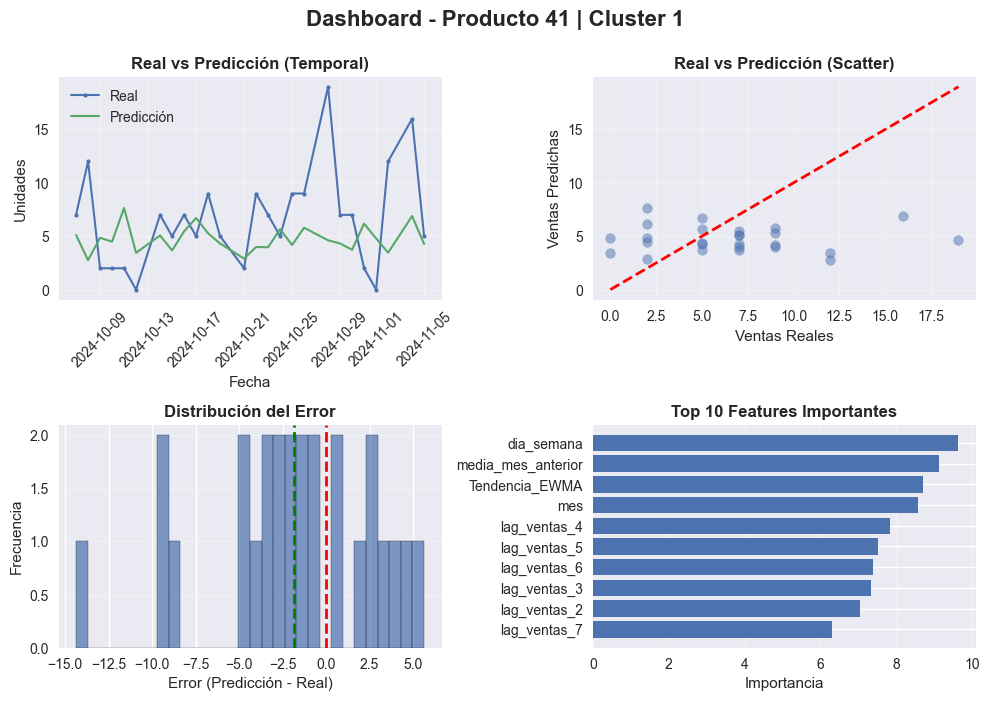


🎯 CLUSTER 2 - Top 2 productos

🔄 Entrenando modelo para Producto 1 (Cluster 2)...

📊 RESUMEN DE MÉTRICAS
               Algoritmo   MAE      MSE    RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
CatBoost Producto 1 (C2) 8.554 140.9254 11.8712 -0.1358     114.5       76.1 0.7474    72.44

🏆 Mejor modelo: CatBoost Producto 1 (C2) (RMSE: 11.8712)


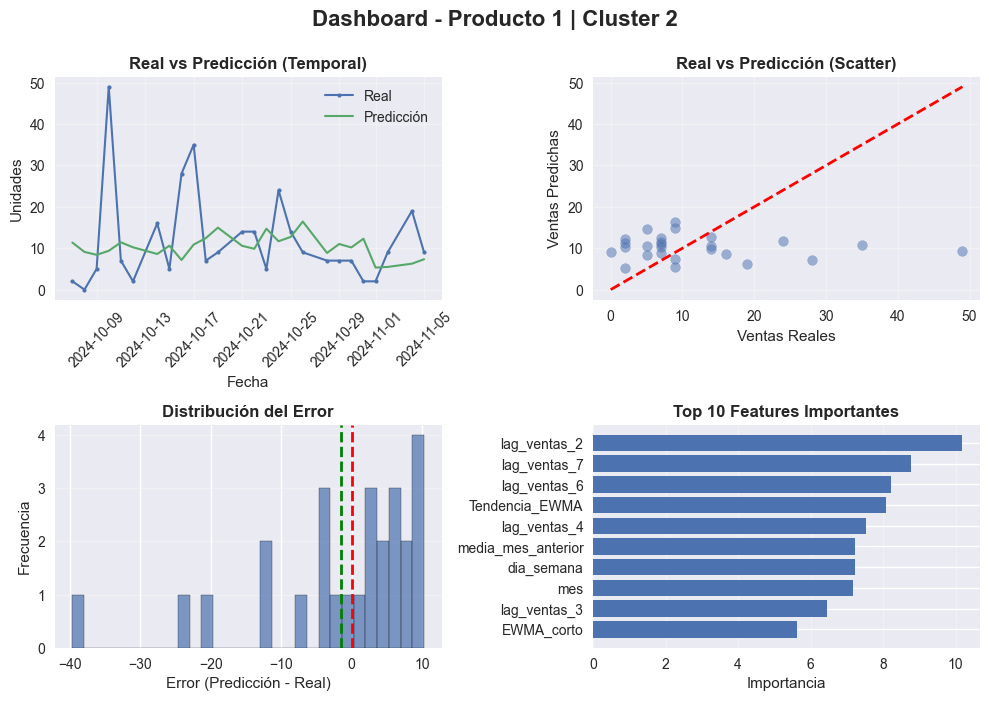


🔄 Entrenando modelo para Producto 2 (Cluster 2)...

📊 RESUMEN DE MÉTRICAS
               Algoritmo    MAE     MSE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
CatBoost Producto 2 (C2) 4.0034 23.2409 4.8209 -0.1368     85.15      70.52 0.6698    63.47

🏆 Mejor modelo: CatBoost Producto 2 (C2) (RMSE: 4.8209)


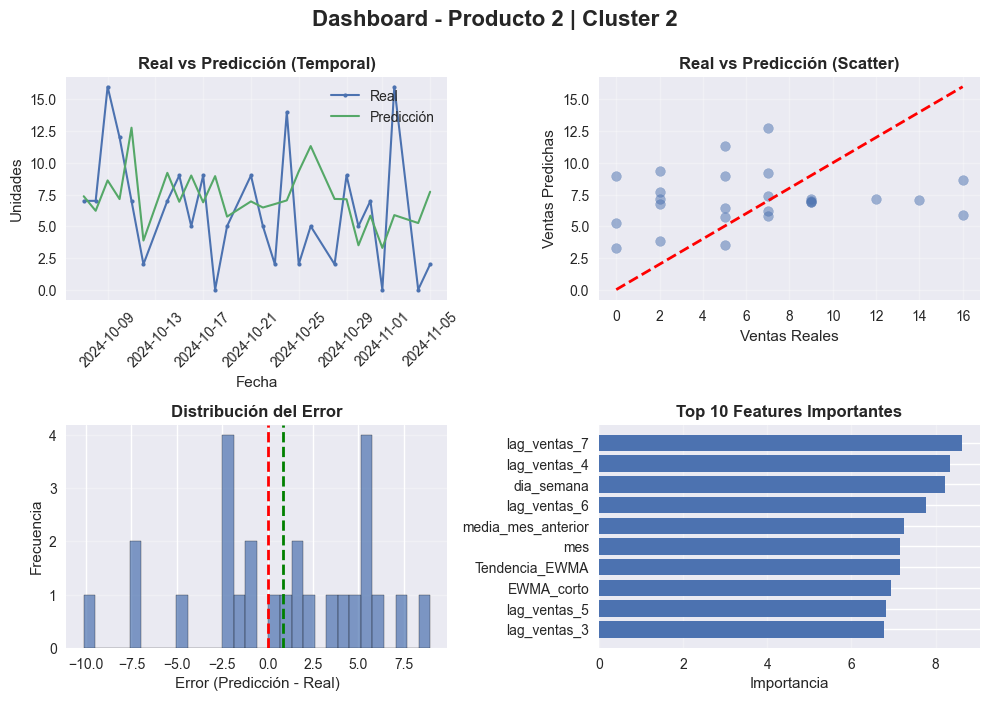


🎯 CLUSTER 3 - Top 2 productos

🔄 Entrenando modelo para Producto 257 (Cluster 3)...

📊 RESUMEN DE MÉTRICAS
                 Algoritmo    MAE    MSE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
CatBoost Producto 257 (C3) 1.2109 2.5916 1.6098 -0.9531     64.84      181.8 1.0954   242.18

🏆 Mejor modelo: CatBoost Producto 257 (C3) (RMSE: 1.6098)


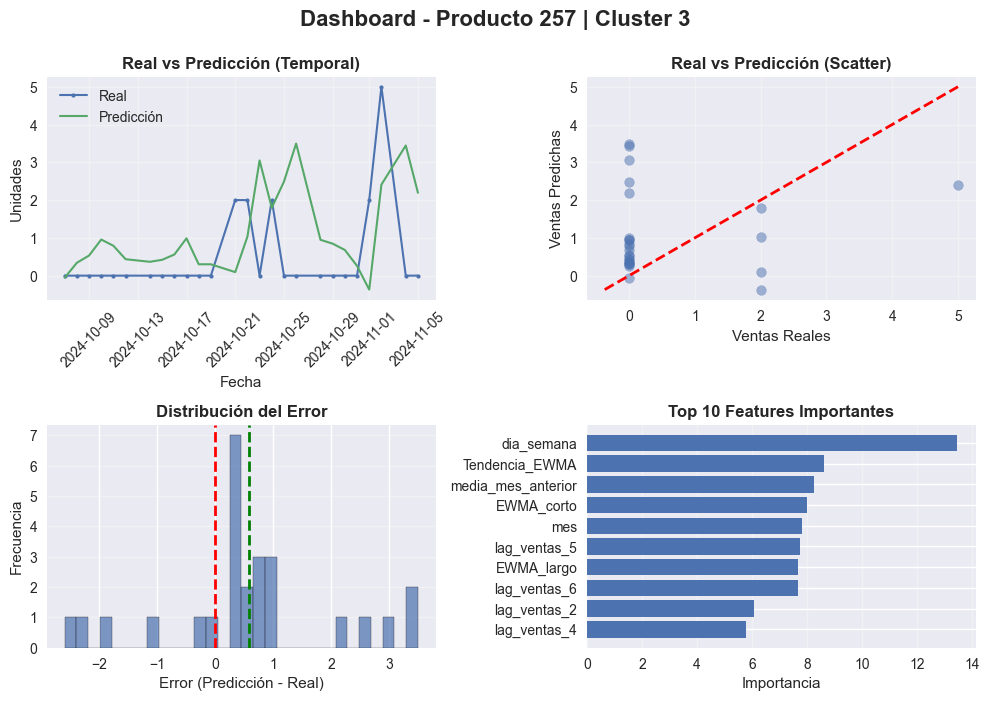


🔄 Entrenando modelo para Producto 314 (Cluster 3)...

📊 RESUMEN DE MÉTRICAS
                 Algoritmo    MAE    MSE   RMSE  R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
CatBoost Producto 314 (C3) 0.2956 0.1104 0.3323 0.0       NaN      200.0    NaN      NaN

🏆 Mejor modelo: CatBoost Producto 314 (C3) (RMSE: 0.3323)


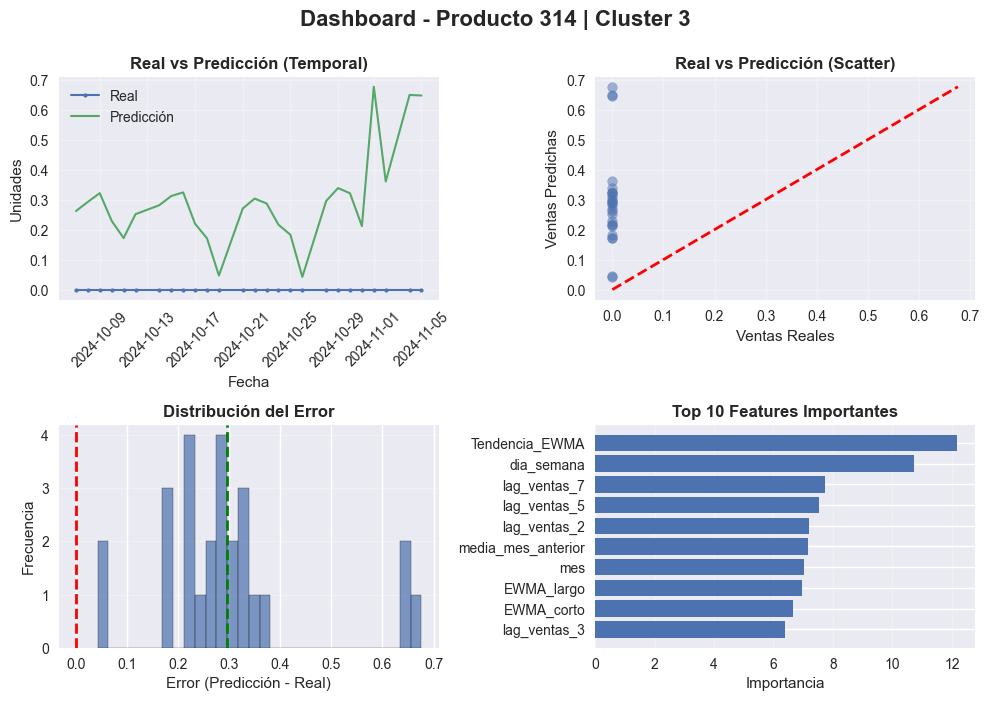


✅ Modelos por producto completados: 8 modelos entrenados


In [17]:
# ============================================================================
# 3. MODELOS POR PRODUCTO TOP (2 POR CLUSTER)
# ============================================================================

print("\n" + "="*100)
print("📍 MODELO 3: XGBoost POR PRODUCTO TOP (2 POR CLUSTER)")
print("="*100)

modelos_producto = {}

# Obtener los 2 productos top por cluster
productos_top_cluster = obtener_top_productos_por_cluster(
    df=df_train,
    col_ventas='udsVenta',
    col_cluster='Cluster',
    col_producto='producto',
    n_productos=2
)

# Iterar por cada cluster y sus productos top
for cluster, productos in productos_top_cluster.items():
    print(f"\n{'='*100}")
    print(f"🎯 CLUSTER {cluster} - Top {len(productos)} productos")
    print(f"{'='*100}")
    
    for producto in productos:
        print(f"\n🔄 Entrenando modelo para Producto {producto} (Cluster {cluster})...")
        
        # Filtrar datos por cluster y producto
        train_prod = df_train[(df_train['Cluster'] == cluster) & (df_train['producto'] == producto)]
        test_prod = df_test[(df_test['Cluster'] == cluster) & (df_test['producto'] == producto)].dropna()
        
        # Preparar características y target
        X_train_p = train_prod[FEATURES]
        y_train_p = train_prod[TARGET]
        X_test_p = test_prod[FEATURES]
        y_test_p = test_prod[TARGET]
        
        # Entrenar modelo con los mejores hiperparámetros de Optuna
        catboost_prod = CatBoostRegressor(
            **study_catboost.best_params,
            random_state=42)
        
        catboost_prod.fit(X_train_p, y_train_p, verbose=False)
        y_pred_p = catboost_prod.predict(X_test_p)
        
        # Guardar modelo
        modelos_producto[f"C{cluster}_P{producto}"] = catboost_prod
        
        # Calcular métricas y GUARDAR
        metricas_producto = calcular_metricas(y_test_p, y_pred_p, f"CatBoost Producto {producto} (C{cluster})")
        todas_metricas.append(metricas_producto)
        resumen_metricas([metricas_producto])
                
        # Preparar datos para visualización
        test_prod_pred = test_prod.copy()
        test_prod_pred['prediccion'] = y_pred_p
        test_prod_pred['error'] = y_pred_p - test_prod_pred[TARGET]
        test_prod_pred['error_abs'] = np.abs(test_prod_pred['error'])
        test_prod_pred['error_pct'] = (test_prod_pred['error_abs'] / (test_prod_pred[TARGET] + 1e-10)) * 100
        test_prod_pred = test_prod_pred.sort_values('idSecuencia')
        
        # Dashboard de predicción
        dashboard_prediccion(
            df=test_prod_pred,
            col_fecha='idSecuencia',
            col_real=TARGET,
            col_pred='prediccion',
            modelo=catboost_prod,
            feature_names=FEATURES,
            titulo_principal=f'Dashboard - Producto {producto} | Cluster {cluster}',
            figsize=(10, 7)
            )

print(f"\n{'='*100}")
print(f"✅ Modelos por producto completados: {len(modelos_producto)} modelos entrenados")
print(f"{'='*100}")


# Resumen final


🏆 RESUMEN FINAL - COMPARACIÓN DE TODOS LOS MODELOS

📊 Resumen de todas las métricas:

📊 RESUMEN DE MÉTRICAS
                             Algoritmo    MAE      MSE    RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
        XGBoost Cluster 3 Producto 314 0.1751   0.0543  0.2330  0.0000       NaN     200.00    NaN      NaN
            CatBoost Producto 314 (C3) 0.2956   0.1104  0.3323  0.0000       NaN     200.00    NaN      NaN
CatBoost Global Cluster 3 Producto 314 0.3829   0.1626  0.4032  0.0000       NaN     200.00    NaN      NaN
CatBoost Global Cluster 3 Producto 257 0.8904   1.3331  1.1546 -0.0046     74.18     184.98 0.7856   178.08
        XGBoost Cluster 3 Producto 257 0.9430   1.5247  1.2348 -0.1490     78.12     186.78 0.8402   188.59
            CatBoost Producto 257 (C3) 1.2109   2.5916  1.6098 -0.9531     64.84     181.80 1.0954   242.18
             CatBoost Global Cluster 3 1.0844   2.7448  1.6567  0.0803     55.20     168.95 0.7434   133.53
                    CatBoos

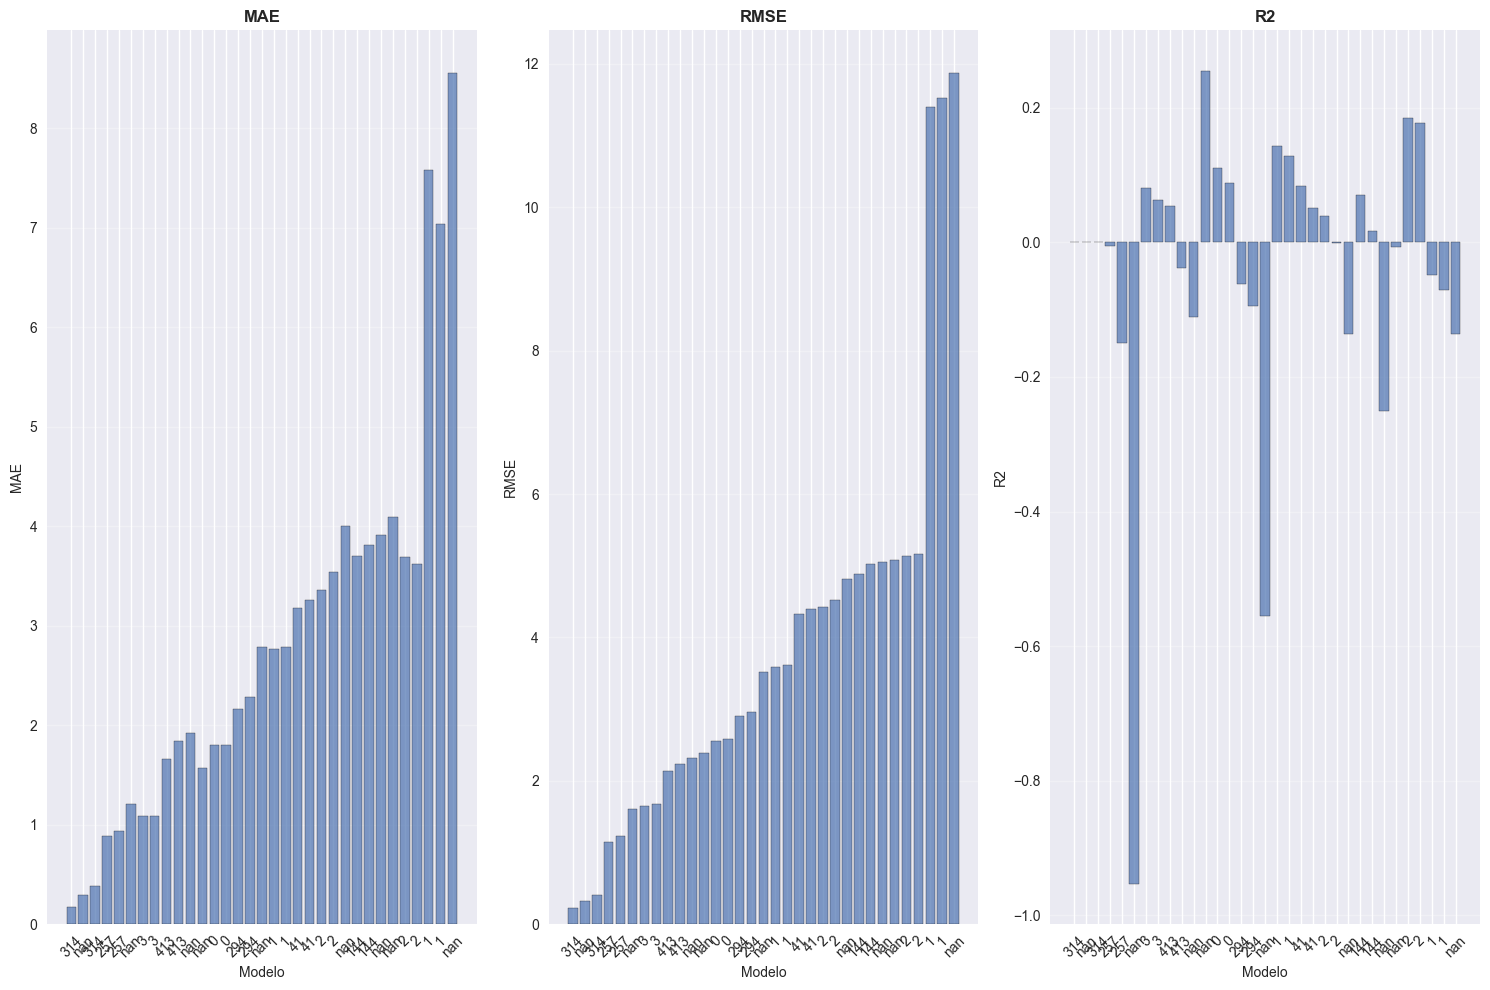


📊 ANÁLISIS POR CATEGORÍAS DE MODELOS

🌍 MODELOS GLOBALES:
                             Algoritmo    MAE    RMSE      R2
CatBoost Global Cluster 3 Producto 314 0.3829  0.4032  0.0000
CatBoost Global Cluster 3 Producto 257 0.8904  1.1546 -0.0046
             CatBoost Global Cluster 3 1.0844  1.6567  0.0803
CatBoost Global Cluster 0 Producto 413 1.6570  2.1395  0.0543
                  CatBoost Global Test 1.5724  2.3897  0.2548
             CatBoost Global Cluster 0 1.8068  2.5906  0.0882
CatBoost Global Cluster 0 Producto 294 2.1625  2.9105 -0.0620
             CatBoost Global Cluster 1 2.7654  3.5904  0.1426
 CatBoost Global Cluster 1 Producto 41 3.1737  4.3227  0.0836
  CatBoost Global Cluster 2 Producto 2 3.3642  4.4308  0.0397
CatBoost Global Cluster 1 Producto 144 3.8063  5.0250  0.0170
             CatBoost Global Cluster 2 3.6251  5.1591  0.1775
  CatBoost Global Cluster 2 Producto 1 7.0326 11.5236 -0.0702

   Promedio RMSE: 3.64

🎯 MODELOS POR CLUSTER:
                         

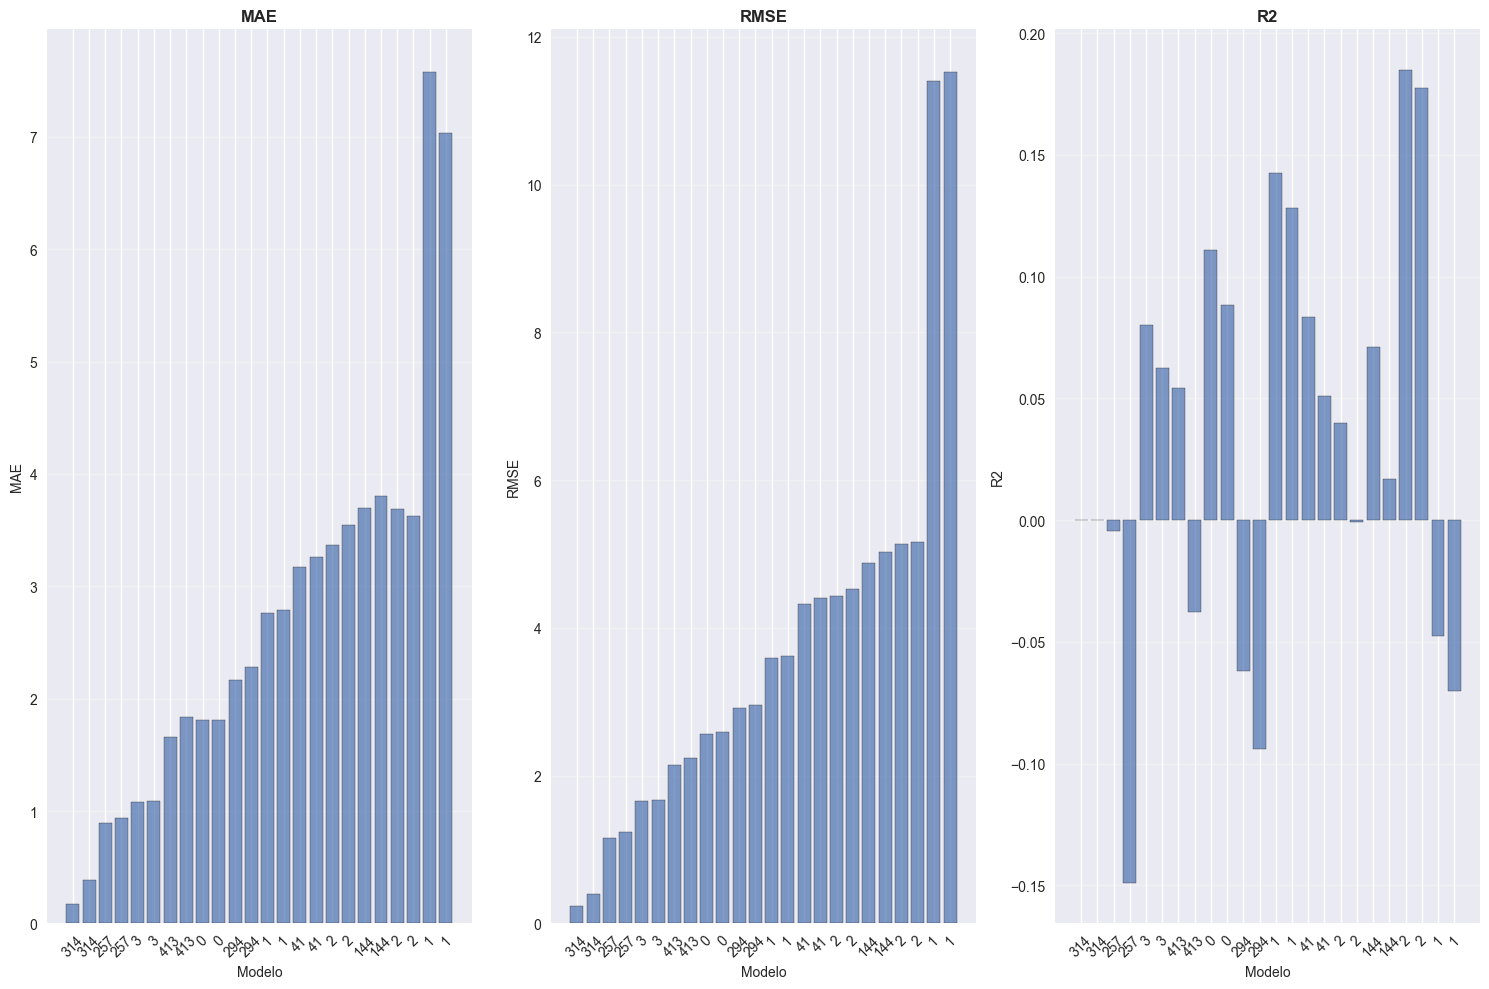


📊 Comparación entre productos:


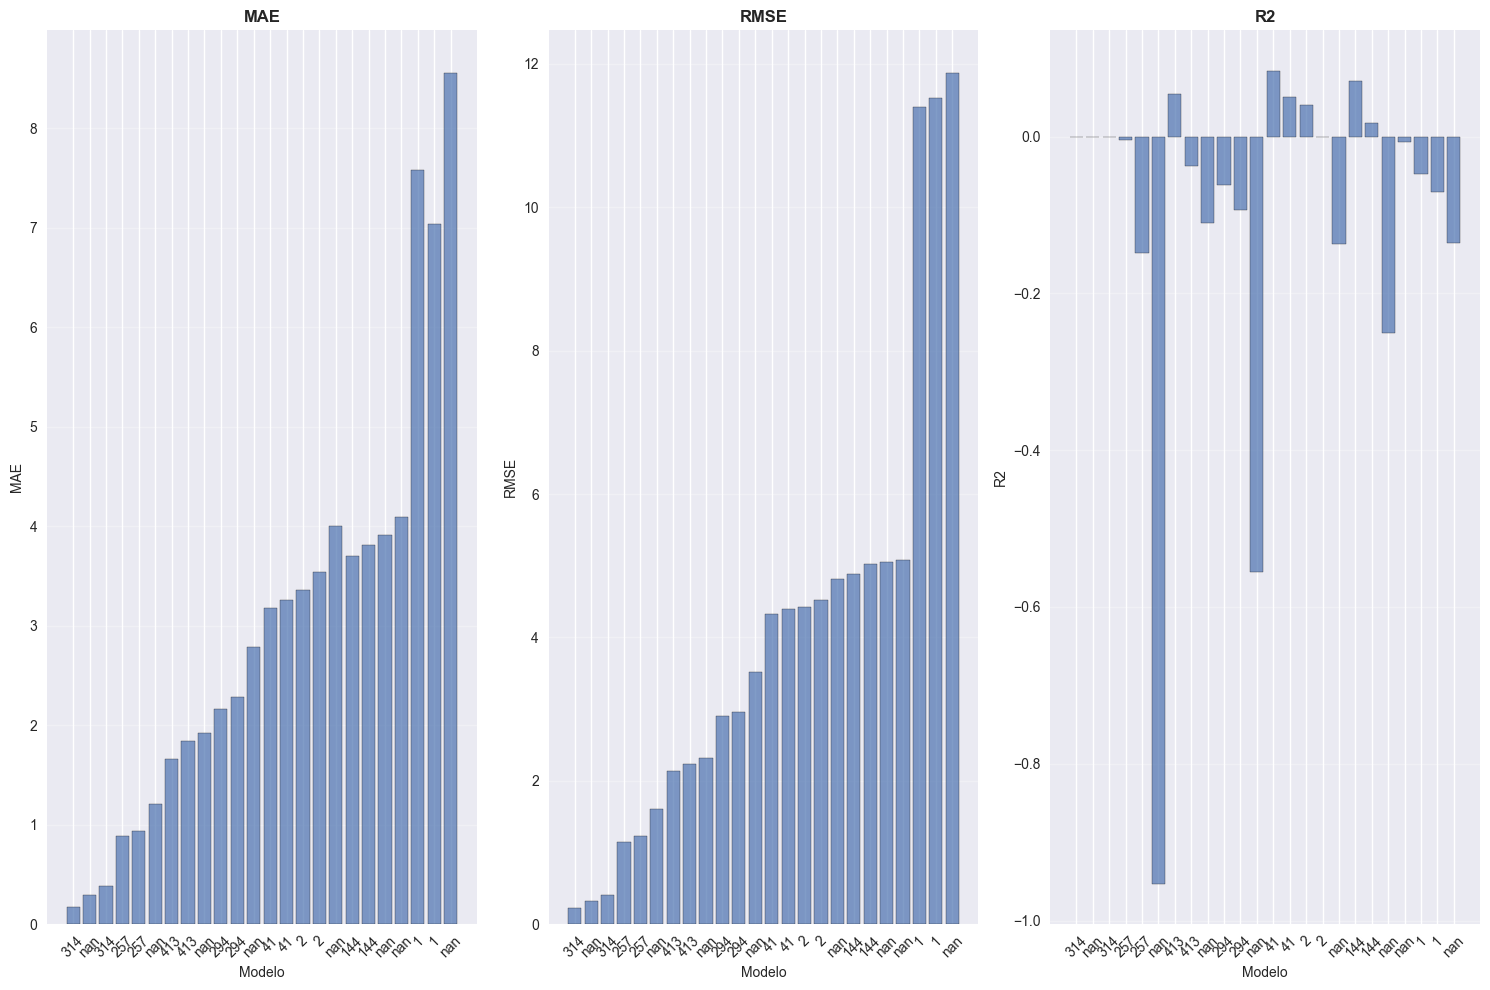


✅ ANÁLISIS COMPLETO FINALIZADO

📊 Total de modelos evaluados: 33
   - Modelos globales: 13
   - Modelos por cluster: 24
   - Modelos por producto: 24


In [18]:

# ============================================================================
# 4. RESUMEN FINAL DE TODOS LOS MODELOS
# ============================================================================

print("\n" + "="*100)
print("🏆 RESUMEN FINAL - COMPARACIÓN DE TODOS LOS MODELOS")
print("="*100)

if todas_metricas:
    # Mostrar tabla completa de métricas
    print("\n📊 Resumen de todas las métricas:")
    resumen_metricas(todas_metricas)
    
    # Comparar métricas
    df_comparacion_final = comparar_metricas(todas_metricas, ordenar_por='RMSE')
    
    print("\n" + "="*100)
    print("📈 RANKING DE MODELOS POR RMSE")
    print("="*100)
    print(df_comparacion_final[['Algoritmo', 'MAE', 'RMSE', 'R2', 'MAPE (%)']].to_string(index=False))
    
    # Gráfico comparativo de TODOS los modelos
    print("\n📊 Generando gráficos comparativos...")
    grafico_comparacion_metricas(df_comparacion_final, metricas=['MAE', 'RMSE', 'R2'])
    
    # Análisis por categorías
    print("\n" + "="*100)
    print("📊 ANÁLISIS POR CATEGORÍAS DE MODELOS")
    print("="*100)
    
    # Separar por tipo de modelo
    df_global = df_comparacion_final[df_comparacion_final['Algoritmo'].str.contains('Global')]
    df_clusters = df_comparacion_final[df_comparacion_final['Algoritmo'].str.contains('Cluster')]
    df_productos = df_comparacion_final[df_comparacion_final['Algoritmo'].str.contains('Producto')]
    
    print("\n🌍 MODELOS GLOBALES:")
    if len(df_global) > 0:
        print(df_global[['Algoritmo', 'MAE', 'RMSE', 'R2']].to_string(index=False))
        print(f"\n   Promedio RMSE: {df_global['RMSE'].mean():.2f}")
    
    print("\n🎯 MODELOS POR CLUSTER:")
    if len(df_clusters) > 0:
        print(df_clusters[['Algoritmo', 'MAE', 'RMSE', 'R2']].to_string(index=False))
        print(f"\n   Promedio RMSE: {df_clusters['RMSE'].mean():.2f}")
        print(f"   Mejor cluster: {df_clusters.iloc[0]['Algoritmo']} (RMSE: {df_clusters.iloc[0]['RMSE']:.2f})")
        print(f"   Peor cluster: {df_clusters.iloc[-1]['Algoritmo']} (RMSE: {df_clusters.iloc[-1]['RMSE']:.2f})")
    
    print("\n🛒 MODELOS POR PRODUCTO:")
    if len(df_productos) > 0:
        print(df_productos[['Algoritmo', 'MAE', 'RMSE', 'R2']].to_string(index=False))
        print(f"\n   Promedio RMSE: {df_productos['RMSE'].mean():.2f}")
        print(f"   Mejor producto: {df_productos.iloc[0]['Algoritmo']} (RMSE: {df_productos.iloc[0]['RMSE']:.2f})")
        print(f"   Peor producto: {df_productos.iloc[-1]['Algoritmo']} (RMSE: {df_productos.iloc[-1]['RMSE']:.2f})")
    
    # Mejor modelo general
    print("\n" + "="*100)
    print("🥇 MEJOR MODELO GENERAL")
    print("="*100)
    mejor_idx = df_comparacion_final['RMSE'].idxmin()
    mejor_modelo = df_comparacion_final.loc[mejor_idx]
    
    print(f"\n🏆 {mejor_modelo['Algoritmo']}")
    print(f"   MAE:        {mejor_modelo['MAE']:.2f}")
    print(f"   RMSE:       {mejor_modelo['RMSE']:.2f}")
    print(f"   R²:         {mejor_modelo['R2']:.4f}")
    print(f"   MAPE:       {mejor_modelo['MAPE (%)']:.2f}%")
    print(f"   SMAPE:      {mejor_modelo['SMAPE (%)']:.2f}%")
    
    # Gráficos comparativos por categoría
    if len(df_clusters) > 1:
        print("\n📊 Comparación entre clusters:")
        grafico_comparacion_metricas(df_clusters, metricas=['MAE', 'RMSE', 'R2'])
    
    if len(df_productos) > 1:
        print("\n📊 Comparación entre productos:")
        grafico_comparacion_metricas(df_productos, metricas=['MAE', 'RMSE', 'R2'])
    
else:
    print("\n⚠️  No se generaron métricas para ningún modelo")

print("\n" + "="*100)
print("✅ ANÁLISIS COMPLETO FINALIZADO")
print("="*100)
print(f"\n📊 Total de modelos evaluados: {len(todas_metricas)}")
print(f"   - Modelos globales: {len([m for m in todas_metricas if 'Global' in m['Algoritmo']])}")
print(f"   - Modelos por cluster: {len([m for m in todas_metricas if 'Cluster' in m['Algoritmo']])}")
print(f"   - Modelos por producto: {len([m for m in todas_metricas if 'Producto' in m['Algoritmo']])}")


# Salvar resultados

In [19]:

# Salvar resultados en fichero
df_resultados = pd.DataFrame(todas_metricas)
df_resultados.to_csv('datos/resultados_metricas_catboost.csv', index=False)
print("\nResultados guardados en 'datos/resultados_metricas_catboost.csv'")


Resultados guardados en 'datos/resultados_metricas_catboost.csv'
